In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [68]:
# LinearRegressionModel (scratch __version__)
# Formula: y = a + bx
# a: bias (intercepter)
# b: weight (slope)
# x: imaginary number

weight = 0.7
bias = 0.3

# PyTorch RandomSeed
torch.manual_seed(42)

X = torch.arange(0, 10, 0.1).unsqueeze(dim=1)
y = bias + weight * X

In [69]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

len(X_train), len(X_test), len(y_train), len(y_test)

(80, 20, 80, 20)

In [70]:
# LinearRegressionModel (PyTorch __version__)

class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = torch.nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))
        self.bias = torch.nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
            return self.bias + self.weights * x

In [71]:
model = LinearRegressionModel()

In [72]:
with torch.inference_mode():
    y_pred = model(X_test)

In [73]:
X_train.shape, y_train.shape

(torch.Size([80, 1]), torch.Size([80, 1]))

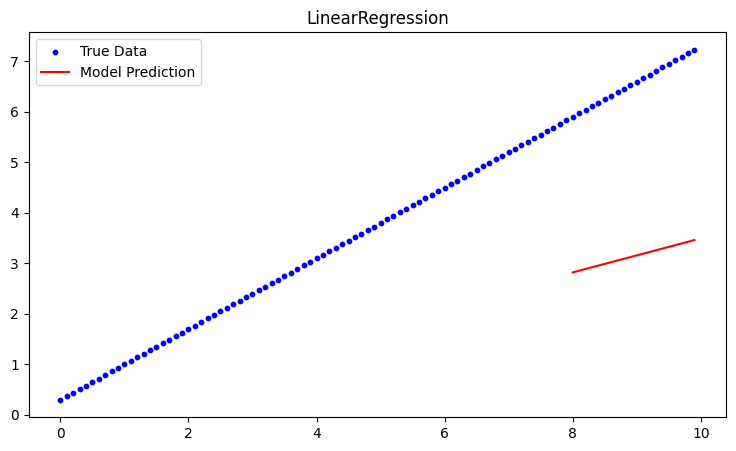

In [76]:
plt.figure(figsize=(9, 5))
plt.title("LinearRegression")
plt.scatter(X, y, label="True Data", c="blue", s=10)
plt.plot(X_test, y_pred, label="Model Prediction", c="red")
plt.legend()
plt.show()